In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
df = pd.read_csv('used_cars.csv')
df.head()


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


Data Exploration

In [6]:
df.shape

(4009, 12)

In [7]:
df.columns

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [9]:
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


EDA & Data Preprocessing

In [10]:
df.isnull().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,170
engine,0
transmission,0
ext_col,0
int_col,0
accident,113


In [11]:
df = df.ffill()

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df = df.drop_duplicates()

In [14]:
# Fill missing values

df['fuel_type'] = df['fuel_type'].fillna('Unknown')
df['accident'] = df['accident'].fillna('No Info')
df['clean_title'] = df['clean_title'].fillna('No Info')

In [15]:
df.dropna(inplace=True)

In [16]:
df.isnull().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,0
engine,0
transmission,0
ext_col,0
int_col,0
accident,0


In [17]:
pd.set_option('display.max_rows',1700)

In [18]:
cols = ['brand','model','fuel_type','engine','transmission','ext_col','int_col','accident']
unique_data = []

for col in cols:
    unique_data.append({
        "Column": col,
        "Unique Count": df[col].nunique(),
        "Unique Values": df[col].unique()
    })

unique_df = pd.DataFrame(unique_data)
unique_df


,Column,Unique Count,Unique Values
0,brand,57,"[Ford, Hyundai, Lexus, INFINITI, Audi, Acura, ..."
1,model,1898,"[Utility Police Interceptor Base, Palisade SEL..."
2,fuel_type,7,"[E85 Flex Fuel, Gasoline, Hybrid, Diesel, Plug..."
3,engine,1146,[300.0HP 3.7L V6 Cylinder Engine Flex Fuel Cap...
4,transmission,62,"[6-Speed A/T, 8-Speed Automatic, Automatic, 7-..."
5,ext_col,319,"[Black, Moonlight Cloud, Blue, Glacier White M..."
6,int_col,156,"[Black, Gray, Ebony., Green, Pimento / Ebony, ..."
7,accident,2,"[At least 1 accident or damage reported, None ..."


In [19]:
pd.reset_option('display.max_rows')

In [20]:
df.drop(columns=['clean_title'], inplace=True)


In [21]:
def simplify_brand(x):
    economy_brands = [ 'Ford', 'Toyota', 'Honda', 'Nissan', 'Hyundai', 'Kia', 'Mazda', 'Subaru', 'Volkswagen']
    luxury_brands = ['BMW', 'Mercedes-Benz', 'Audi', 'Lexus', 'Cadillac', 'Acura', 'Infiniti']
    exotic_brands = ['Ferrari', 'Lamborghini', 'McLaren', 'Bugatti', 'Pagani', 'Koenigsegg', 'Jaguar', 'Porsche', 'Maserati', 'Aston Martin', 'Bentley', 'Rolls-Royce']
    electric_brands = ['Tesla', 'Rivian', 'Lucid Motors', 'NIO', 'XPeng', 'BYD', 'Fisker']

    if x in economy_brands:
        return 'Economy'
    elif x in luxury_brands:
        return 'Luxury'
    elif x in exotic_brands:
        return 'Exotic'
    elif x in electric_brands:
        return 'Electric'
    else:
        return 'Other'

df['brand'] = df['brand'].apply(simplify_brand)
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,price
0,Economy,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,"$10,300"
1,Economy,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,"$38,005"
2,Luxury,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,"$54,598"
3,Other,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,"$15,500"
4,Luxury,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,"$34,999"


In [22]:
df['model_main'] = df['model'].apply(lambda x: x.split()[0])
df.head()

#Example
#model	            model_main
#Corolla Altis	    Corolla
#Swift Dzire	    Swift
#BMW X5 xDrive	    BMW

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,price,model_main
0,Economy,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,"$10,300",Utility
1,Economy,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,"$38,005",Palisade
2,Luxury,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,"$54,598",RX
3,Other,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,"$15,500",Q50
4,Luxury,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,"$34,999",Q3


In [23]:
top_models = df['model_main'].value_counts().nlargest(10).index
df['model_main'] = df['model_main'].apply(lambda x: x if x in top_models else 'Other')
df.head()

#Example

#Before: model_main     After: model_main
#Swift                  Swift
#BMW                    BMW
#Civic                  Civic
#RareCar1               Other
#RareCar2               Other

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,price,model_main
0,Economy,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,"$10,300",Other
1,Economy,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,"$38,005",Other
2,Luxury,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,"$54,598",Other
3,Other,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,"$15,500",Other
4,Luxury,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,"$34,999",Other


In [24]:
df['model_main'].value_counts()

,count
model_main,
Other,3290
Rover,130
Model,87
911,80
Wrangler,73
F-150,64
Mustang,61
Corvette,61
AMG,60


In [25]:
df['fuel_type'].unique()

array(['E85 Flex Fuel', 'Gasoline', 'Hybrid', 'Diesel', 'Plug-In Hybrid',
       '–', 'not supported'], dtype=object)

In [26]:
df['fuel_type'] = df['fuel_type'].fillna('Unknown')


In [27]:
def simplify_fuel(x):
    if x == 'Gasoline':
        return 'Gasoline'
    elif 'Hybrid' in str(x):
        return 'Hybrid'
    elif x == 'Diesel':
        return 'Diesel'
    elif x == 'Electric':
        return 'Electric'
    else:
        return 'Other'

df['fuel_type'] = df['fuel_type'].apply(simplify_fuel)
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,price,model_main
0,Economy,Utility Police Interceptor Base,2013,"51,000 mi.",Other,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,"$10,300",Other
1,Economy,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,"$38,005",Other
2,Luxury,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,"$54,598",Other
3,Other,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,"$15,500",Other
4,Luxury,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,"$34,999",Other


In [28]:
df['fuel_type'].value_counts()

,count
fuel_type,
Gasoline,3453
Hybrid,235
Other,199
Diesel,122


In [29]:
engine_str = df['engine'].astype(str)
df['HP'] = engine_str.str.extract(r'(\d+)\s*HP', expand=False).astype(float)
df['Engine_size'] = engine_str.str.extract(r'(\d+\.\d+)', expand=False).astype(float)
df['Cylinders'] = engine_str.str.extract(r'(\d+)(?!.*\d)', expand=False).astype(float)

#| engine         | HP  | Engine_size | Cylinders |
#|-------------- | --- | ----------- | --------- |
#| 300 HP 3.0L V6 | 300 | 3.0         | 6         |
#| 150 HP 1.5L V4 | 150 | 1.5         | 4         |


In [30]:
df.isna().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,0
engine,0
transmission,0
ext_col,0
int_col,0
accident,0


In [31]:
df['HP'] = df['HP'].fillna(df['HP'].median())
df['Engine_size'] = df['Engine_size'].fillna(df['Engine_size'].median())
df['Cylinders'] = df['Cylinders'].fillna(df['Cylinders'].median())

In [32]:
df.isna().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,0
engine,0
transmission,0
ext_col,0
int_col,0
accident,0


In [33]:
def simplify_transmission(x):
    x = str(x)
    if 'A/T' in x or 'Automatic' in x:
        return 'Automatic'
    elif 'M/T' in x or 'Manual' in x:
        return 'Manual'
    elif 'CVT' in x:
        return 'CVT'
    else:
        return 'Other'

df['transmission'] = df['transmission'].apply(simplify_transmission)

In [34]:
df['transmission'].value_counts()

,count
transmission,
Automatic,3148
Other,426
Manual,372
CVT,63


In [35]:
main_colors = ['white', 'black', 'silver', 'gray', 'red', 'blue']

df['ext_col'] = df['ext_col'].str.lower().apply(
    lambda x: next((color.capitalize() for color in main_colors if color in str(x)), 'Other')
)

df['int_col'] = df['int_col'].str.lower().apply(
    lambda x: next((color.capitalize() for color in main_colors if color in str(x)), 'Other')
)
#| ext_col (before) | ext_col (after) |
#| ---------------- | --------------- |
#| White            | White           |
#| Yellow           | Other           |
#| Dark Blue        | Other ❗        |
#| Black            | Black           |

df['ext_col'].value_counts()



,count
ext_col,
Black,1016
White,922
Gray,535
Silver,421
Other,409
Blue,395
Red,311


In [36]:
df['int_col'].value_counts()

,count
int_col,
Black,2155
Other,1058
Gray,483
Red,134
White,131
Blue,32
Silver,16


In [37]:
df['accident'] = df['accident'].replace({'None reported': 'No', 'None ': 'No', 'Accident reported': 'Yes'})
df['accident'] = df['accident'].fillna('No Info')


In [38]:
df['car_age'] = pd.Timestamp.now().year - df['model_year']


In [39]:
df

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,price,model_main,HP,Engine_size,Cylinders,car_age
0,Economy,Utility Police Interceptor Base,2013,"51,000 mi.",Other,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,Automatic,Black,Black,At least 1 accident or damage reported,"$10,300",Other,0.0,300.0,6.0,13
1,Economy,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,Automatic,Other,Gray,At least 1 accident or damage reported,"$38,005",Other,0.0,3.8,24.0,5
2,Luxury,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,No,"$54,598",Other,0.0,3.5,5.0,4
3,Other,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,Automatic,Black,Black,No,"$15,500",Other,0.0,354.0,6.0,11
4,Luxury,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,Automatic,White,Black,No,"$34,999",Other,0.0,2.0,16.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4004,Exotic,Continental GT Speed,2023,714 mi.,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,Automatic,Other,Other,No,"$349,950",Other,0.0,6.0,48.0,3
4005,Luxury,S4 3.0T Premium Plus,2022,"10,900 mi.",Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Other,Black,Black,No,"$53,900",Other,0.0,349.0,6.0,4
4006,Exotic,Taycan,2022,"2,116 mi.",Gasoline,Electric,Automatic,Black,Black,No,"$90,998",Other,0.0,290.0,6.0,4
4007,Economy,F-150 Raptor,2020,"33,000 mi.",Gasoline,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,Automatic,Blue,Black,No,"$62,999",F-150,0.0,450.0,6.0,6


In [40]:
df.drop(columns=['brand', 'model', 'model_year', 'engine'], inplace=True)
df


,milage,fuel_type,transmission,ext_col,int_col,accident,price,model_main,HP,Engine_size,Cylinders,car_age
0,"51,000 mi.",Other,Automatic,Black,Black,At least 1 accident or damage reported,"$10,300",Other,0.0,300.0,6.0,13
1,"34,742 mi.",Gasoline,Automatic,Other,Gray,At least 1 accident or damage reported,"$38,005",Other,0.0,3.8,24.0,5
2,"22,372 mi.",Gasoline,Automatic,Blue,Black,No,"$54,598",Other,0.0,3.5,5.0,4
3,"88,900 mi.",Hybrid,Automatic,Black,Black,No,"$15,500",Other,0.0,354.0,6.0,11
4,"9,835 mi.",Gasoline,Automatic,White,Black,No,"$34,999",Other,0.0,2.0,16.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...
4004,714 mi.,Gasoline,Automatic,Other,Other,No,"$349,950",Other,0.0,6.0,48.0,3
4005,"10,900 mi.",Gasoline,Other,Black,Black,No,"$53,900",Other,0.0,349.0,6.0,4
4006,"2,116 mi.",Gasoline,Automatic,Black,Black,No,"$90,998",Other,0.0,290.0,6.0,4
4007,"33,000 mi.",Gasoline,Automatic,Blue,Black,No,"$62,999",F-150,0.0,450.0,6.0,6


In [41]:
df['milage'] = df['milage'].astype(str).str.replace(',', '', regex=False)
df['price'] = df['price'].astype(str).str.replace(',', '', regex=False)
df['accident'] = df['accident'].fillna(df['accident'].mode()[0])

df['milage'] = df['milage'].str.extract(r'(\d+)', expand=False).astype(float)
df['price'] = df['price'].str.replace(r'[^\d.]', '', regex=True).astype(float)

#You should see:
#milage ? float ?
#price ? float ?
#accident ? no nulls ?


Visulization

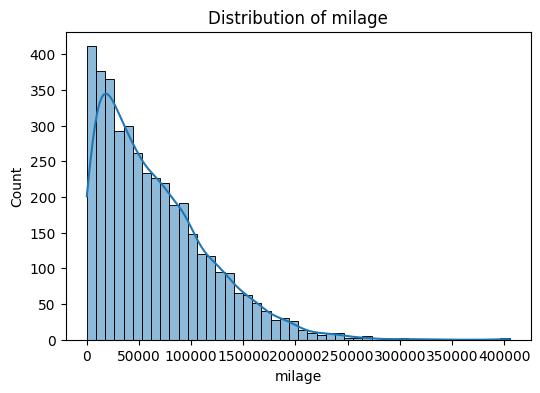

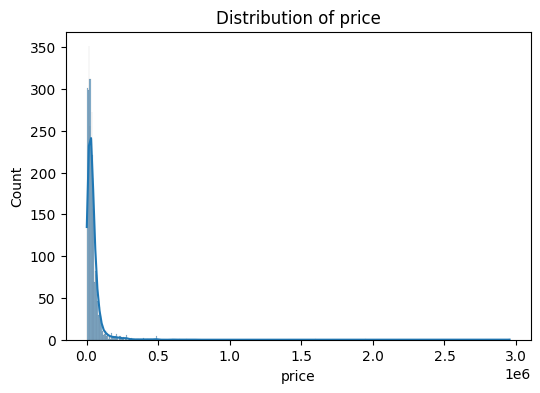

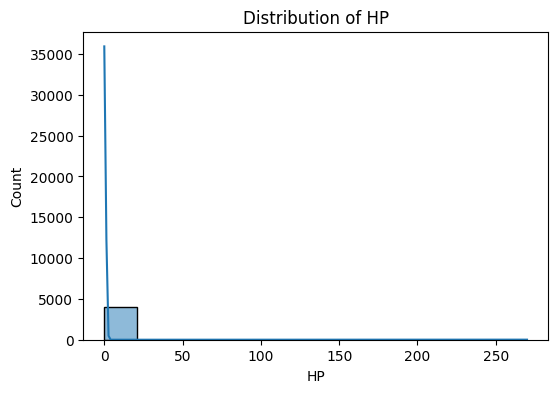

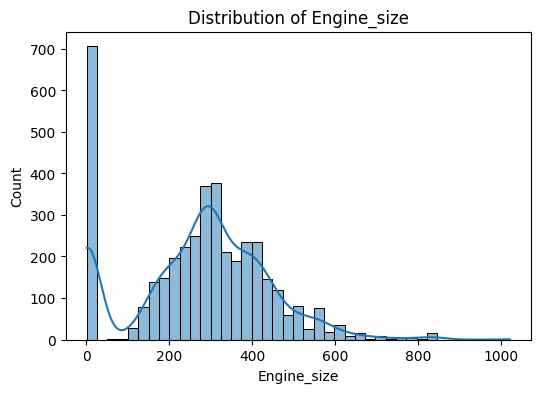

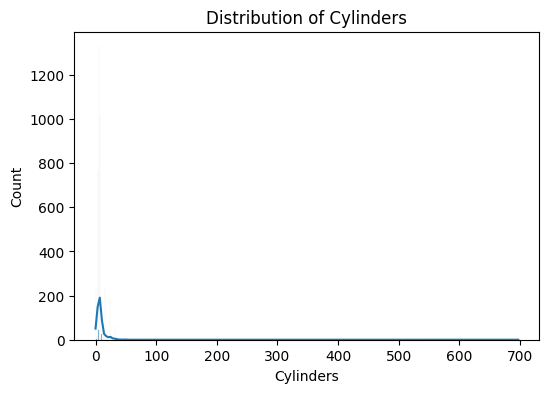

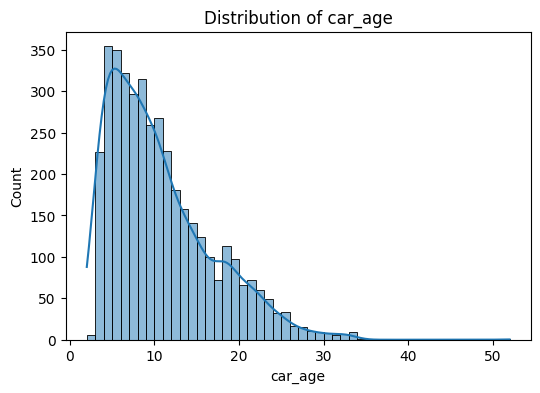

In [42]:
numeric_cols = ['milage', 'price', 'HP', 'Engine_size', 'Cylinders', 'car_age']

for col in numeric_cols:
    if col in df.columns:
        plt.figure(figsize=(6, 4))
        sns.histplot(df[col].dropna(), kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.show()

In [43]:
# Conversions already handled earlier.


In [44]:
print(df[['milage', 'price', 'HP', 'Engine_size', 'Cylinders', 'car_age']].skew())

milage          1.159975
price          19.513551
HP             49.805413
Engine_size     0.043356
Cylinders      29.661079
car_age         1.089231
dtype: float64


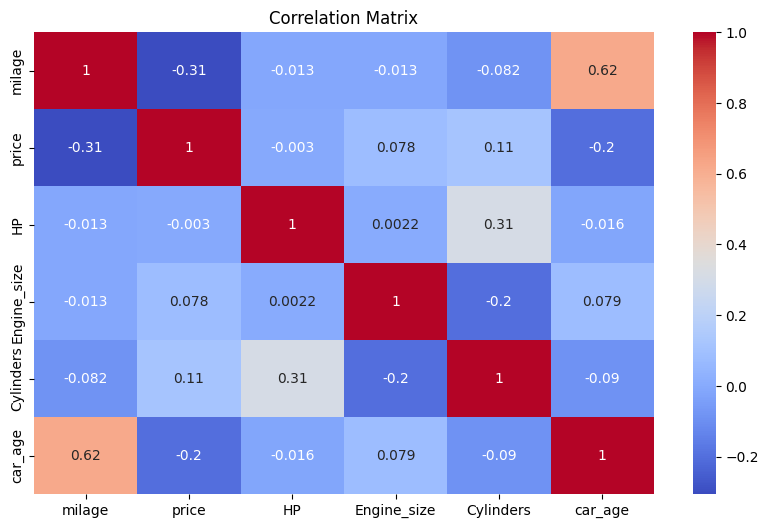

In [45]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Apply One-Hot Encoding

In [46]:
Category_cols = ['fuel_type', 'transmission', 'ext_col', 'int_col', 'accident']

existing_cols = [col for col in Category_cols if col in df.columns]

df = pd.get_dummies(df, columns=existing_cols, drop_first=True)

In [47]:
'''doing proper outlier handling + distribution fixing for price and milage.
We will log transform price and clip milage to remove extreme outliers.'''

df['milage'] = df['milage'].clip(
    df['milage'].quantile(0.01),
    df['milage'].quantile(0.99)
)

df['HP'] = df['HP'].clip(
    df['HP'].quantile(0.01),
    df['HP'].quantile(0.99)
)

df['price'] = np.log1p(df['price'])
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f"Number of outliers in 'price': {outliers.shape[0]}")

#| Before | After                       |
#| ------ | --------------------------- |
#| 500000 | → capped at 99th percentile |


Number of outliers in 'price': 66


In [48]:
'''Removed outliers from price column. You can also choose to cap them instead of removing.'''

df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

X = df.drop('price', axis=1)
y = df['price']

#👉 Keeps only “normal” price values
#👉 Improves model accuracy

Train Test the model

In [49]:
# 1. Split features & target
X = df.drop('price', axis=1)
y = df['price']

# 2. Encode ALL categorical columns
X = pd.get_dummies(X, drop_first=True)

# 3. Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [50]:
numeric_cols = ['milage', 'HP', 'Engine_size', 'Cylinders', 'car_age']
scaler = StandardScaler()


X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [51]:
X_train.select_dtypes(include='object').columns

Index([], dtype='object')

In [52]:
for col in X_train.select_dtypes(include='object').columns:
    print(col, X_train[col].unique()[:5])

In [53]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [54]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.6991429050560927
MAE: 0.3264001615987521
RMSE: 0.4345343772912493


In [55]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

In [56]:
svr_model = SVR()
param_grid = [
    {'kernel': ['linear'], 'C': [0.1, 1, 10]},
    {'kernel': ['rbf'], 'C': [0.1, 1, 10]},
    {'kernel': ['poly'], 'C': [0.1, 1, 10], 'degree': [2, 3, 4]}
]
grid = GridSearchCV(
    estimator=svr_model,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=1
)
grid.fit(X_train, y_train)


GridSearchCV(cv=3, estimator=SVR(), n_jobs=-1,
             param_grid=[{'C': [0.1, 1, 10], 'kernel': ['linear']},
                         {'C': [0.1, 1, 10], 'kernel': ['rbf']},
                         {'C': [0.1, 1, 10], 'degree': [2, 3, 4],
                          'kernel': ['poly']}],
             scoring='r2')

In [57]:
grid.best_params_

{'C': 1, 'kernel': 'rbf'}

In [58]:
model_results = {}

best_model = grid.best_estimator_
predgrid = best_model.predict(X_test)

model_results['SVR'] = predgrid

print(model_results.keys())

dict_keys(['SVR'])


In [59]:
results = []

for model, preds in model_results.items():
    results.append({
        "Model": model,
        "R2 Score": r2_score(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds))   # ✅ fixed
    })

results_df = pd.DataFrame(results)
print(results_df)

  Model  R2 Score      RMSE
0   SVR  0.801464  0.352991


In [60]:
# Save the best model
import joblib
joblib.dump(best_model, 'best_used_car_price_model.pkl')

['best_used_car_price_model.pkl']

In [62]:
import numpy as np

# Create a template DataFrame with all columns from X_train, initialized to 0
input_df_for_prediction = pd.DataFrame(0, index=[0], columns=X_train.columns)

# Fill in the numerical features (these are not scaled yet)
input_df_for_prediction['milage'] = 30000
input_df_for_prediction['HP'] = 150
input_df_for_prediction['Engine_size'] = 2.0
input_df_for_prediction['Cylinders'] = 4
input_df_for_prediction['car_age'] = 5

# Set the appropriate dummy variables to 1 for the desired categorical features.
# Based on common `drop_first=True` behavior and the error messages, we infer the intended categories
# and which dummy variables correspond to them.

# If 'fuel_type' is 'Gasoline', 'transmission' is 'Automatic', 'ext_col' is 'Black',
# 'int_col' is 'Black', and 'model_main' is 'Other' (the base categories after drop_first=True),
# then their corresponding dummy columns will remain 0.

# For 'accident': The error indicated 'accident_No' was a column seen at fit time,
# and 'accident_Yes' was unseen. This suggests `accident_Yes` was dropped.
# So, to represent 'No accident' (as intended by the original `accident_Yes: [0]`),
# we set `accident_No` to 1 if it exists as a column.
if 'accident_No' in input_df_for_prediction.columns:
    input_df_for_prediction['accident_No'] = 1 # For 'No accident'

# Scale the numerical features using the *already fitted* StandardScaler
# `numeric_cols` is available from a previous cell.
input_df_for_prediction[numeric_cols] = scaler.transform(input_df_for_prediction[numeric_cols])

# Make the prediction
prediction_price = best_model.predict(input_df_for_prediction)

print(f"Predicted log price: {prediction_price[0]}")
print(f"Predicted actual price: {np.expm1(prediction_price[0]):.2f}")

Predicted log price: 10.724267582383069
Predicted actual price: 45444.43
